# ATC Readback Verifier — Analysis

This notebook **reproduces our analysis** end to end so the evidence is visible, not
implicit in the `.py` files:

1. the unit-test suite passing,
2. the deterministic comparator on worked examples (every error category),
3. the live LLM extraction pipeline on real examples,
4. the evaluation metrics (precision / recall / F1 / false-alarm / confusion),
5. the **prompt-iteration experiment** (baseline → a hardening attempt that *regressed* → the fix),
6. the **3B vs 7B** model comparison,
7. the failure analysis.

It loads the committed results in `eval/results/runs/`, so re-running it reproduces every
number and figure. The only cell that needs a model is the live-pipeline demo (Ollama);
it is guarded and skipped if Ollama is not running.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Find the repo root from wherever the notebook is opened.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

plt.rcParams.update({"figure.figsize": (9, 4.2), "axes.grid": True, "grid.alpha": 0.3})
print("Repo root:", ROOT)

Matplotlib is building the font cache; this may take a moment.


Repo root: /Users/janwejchert/Desktop/IE Sem3/NLP/NLP


## 1. The unit tests pass
The deterministic comparator (our core logic) is unit-tested with no LLM in the loop.

In [2]:
res = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT,
                     capture_output=True, text=True)
print(res.stdout.strip()[-1500:])

........................                                                 [100%]


## 2. The deterministic comparator
The LLM only extracts fields; **all** verdict logic is deterministic Python. Here it is on
hand-built inputs (no model), showing each error category and the runway-side rule.

In [3]:
from atc_verifier import compare_fields
from atc_verifier.schema import ExtractedFields
from atc_verifier.verdict import build_verdict


def verdict_for(inst_json, rb_json):
    inst = ExtractedFields.from_json(inst_json)
    rb = ExtractedFields.from_json(rb_json)
    return build_verdict(compare_fields(inst, rb))


cases = [
    ("MATCH",
     {"callsign": "Speedbird 245", "altitude": {"kind": "FL", "value": 240}},
     {"callsign": "Speedbird 245", "altitude": {"kind": "FL", "value": 240}}),
    ("value_substitution",
     {"callsign": "Speedbird 245", "altitude": {"kind": "FL", "value": 240}},
     {"callsign": "Speedbird 245", "altitude": {"kind": "FL", "value": 250}}),
    ("digit_transposition",
     {"callsign": "Easy 4471", "squawk": "5701"},
     {"callsign": "Easy 4471", "squawk": "5071"}),
    ("omission",
     {"callsign": "Iberia 6020", "heading": {"value": 120}, "frequency": "118.7"},
     {"callsign": "Iberia 6020", "heading": {"value": 120}}),
    ("callsign_error",
     {"callsign": "Speedbird 245", "altitude": {"kind": "FL", "value": 280}},
     {"callsign": "Speedbird 254", "altitude": {"kind": "FL", "value": 280}}),
    ("added_element",
     {"callsign": "Easy 4471", "frequency": "118.7"},
     {"callsign": "Easy 4471", "frequency": "118.7", "squawk": "7000"}),
    ("runway side ignored (stated in only one msg)",
     {"callsign": "Air Europa 75", "runway": {"number": "06", "side": "left"}},
     {"callsign": "Air Europa 75", "runway": {"number": "06"}}),
]
for label, i, r in cases:
    v = verdict_for(i, r)
    detail = "; ".join(d.detail for d in v.discrepancies) or "(no discrepancies)"
    print(f"{label:46s} -> {v.status:11s} {detail}")

MATCH                                          -> MATCH       (no discrepancies)
value_substitution                             -> DISCREPANCY instructed altitude FL240, read back as FL250
digit_transposition                            -> DISCREPANCY instructed squawk 5701, transposed to 5071
omission                                       -> DISCREPANCY frequency 118.7 not read back
callsign_error                                 -> DISCREPANCY callsign read back as 'speedbird 254' instead of 'speedbird 245'
added_element                                  -> DISCREPANCY squawk 7000 read back but not instructed
runway side ignored (stated in only one msg)   -> MATCH       (no discrepancies)


## 3. The live extraction pipeline
The full pipeline (LLM extraction → comparison → verdict). Needs Ollama with `qwen2.5:3b`;
the cell is guarded so the notebook still runs without it.

In [4]:
try:
    from atc_verifier import verify
    from atc_verifier.extract.base import get_extractor

    ex = get_extractor("ollama", model="qwen2.5:3b")
    demos = [
        ("Speedbird 245, climb flight level 280.", "Climb flight level 280, Speedbird 245."),
        ("Speedbird 245, descend flight level 240.", "Descend flight level 250, Speedbird 245."),
    ]
    for instr, rb in demos:
        r = verify(instr, rb, ex)
        print("INSTRUCTION:", instr)
        print("READBACK   :", rb)
        print("VERDICT    :", r.status)
        print("  extracted (instruction):", r.instruction_fields.raw)
        print("  extracted (readback)   :", r.readback_fields.raw)
        print("-" * 88)
except Exception as e:
    print("Live pipeline skipped (Ollama not running?):", type(e).__name__, e)

INSTRUCTION: Speedbird 245, climb flight level 280.
READBACK   : Climb flight level 280, Speedbird 245.
VERDICT    : MATCH
  extracted (instruction): {'callsign': 'Speedbird 245', 'altitude': {'kind': 'FL', 'value': 280}, 'heading': None, 'speed': None, 'frequency': None, 'squawk': None, 'runway': None, 'qnh': None}
  extracted (readback)   : {'callsign': 'Speedbird 245', 'altitude': {'kind': 'FL', 'value': 280}, 'heading': None, 'speed': None, 'frequency': None, 'squawk': None, 'runway': None, 'qnh': None}
----------------------------------------------------------------------------------------


INSTRUCTION: Speedbird 245, descend flight level 240.
READBACK   : Descend flight level 250, Speedbird 245.
VERDICT    : DISCREPANCY
  extracted (instruction): {'callsign': 'Speedbird 245', 'altitude': {'kind': 'FL', 'value': 240}, 'heading': None, 'speed': None, 'frequency': None, 'squawk': None, 'runway': None, 'qnh': None}
  extracted (readback)   : {'callsign': 'Speedbird 245', 'altitude': {'kind': 'FL', 'value': 250}, 'heading': None, 'speed': None, 'frequency': None, 'squawk': None, 'runway': None, 'qnh': None}
----------------------------------------------------------------------------------------


## 4. Evaluation across all runs
We evaluate on our 50-case labelled test set. Positive class = "read-back contains an error",
so precision/recall/F1 measure error **detection** and the false-alarm rate is how often we
wrongly flag a correct read-back. We load every run we have on disk.

In [5]:
RUNS = {
    "3B · baseline": "eval/results/runs/3b_baseline_v1",
    "3B · hardened (regressed)": "eval/results/runs/3b_improved_v2",
    "3B · final": "eval/results/runs/3b_final_v3",
    "7B · final": "eval/results/runs/7b_final_v3",
}
rows = []
for label, rel in RUNS.items():
    f = ROOT / rel / "metrics.json"
    if not f.exists():
        continue
    m = json.loads(f.read_text())
    rows.append({
        "run": label, "model": m["model"], "n": m["n"],
        "precision": m["precision"], "recall": m["recall"], "f1": m["f1"],
        "false_alarm": m["false_alarm_rate"], "accuracy": m["verdict_accuracy"],
    })
runs_df = pd.DataFrame(rows).set_index("run")
runs_df.round(3)

,model,n,precision,recall,f1,false_alarm,accuracy
run,,,,,,,
3B · baseline,qwen2.5:3b,50,0.943,0.971,0.957,0.125,0.94
3B · hardened (regressed),qwen2.5:3b,50,0.895,1.000,0.944,0.250,0.92
3B · final,qwen2.5:3b,50,0.971,1.000,0.986,0.062,0.98
7B · final,qwen2.5:7b,50,1.000,1.000,1.000,0.000,1.00


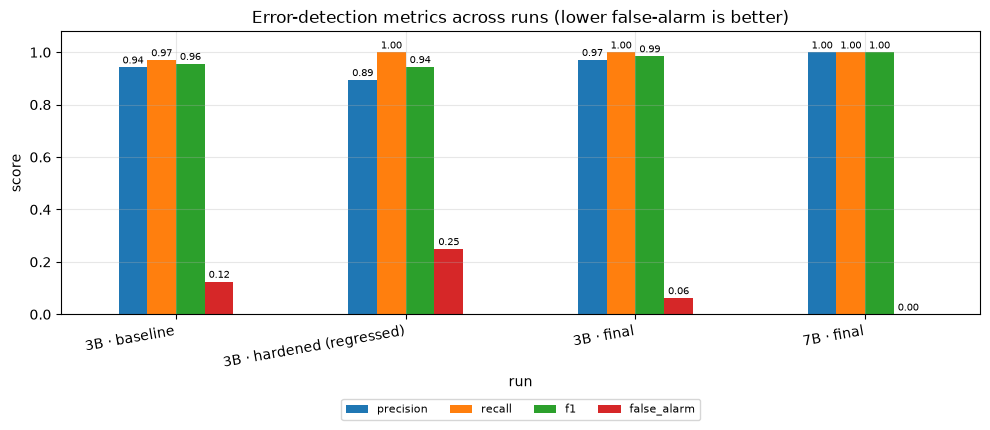

In [6]:
metrics = ["precision", "recall", "f1", "false_alarm"]
ax = runs_df[metrics].plot(kind="bar", figsize=(10, 4.6))
ax.set_ylim(0, 1.08)
ax.set_ylabel("score")
ax.set_title("Error-detection metrics across runs (lower false-alarm is better)")
ax.legend(loc="upper center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.28))
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=1)
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

## 5. The prompt-iteration experiment
We hypothesised that **hardening** the extraction prompt (more rules + examples) would cut the
false-alarm rate. It did the opposite — it **regressed** (recall rose to 100% but the
false-alarm rate roughly doubled). Root cause: the new few-shot examples *poisoned* the small
model — it began reading the 4-digit callsign suffix (e.g. `Easy 4471`) as a squawk and misread
`runway 24` as `heading 240`. We reverted to safe **rules** and added a deterministic
**comparator rule** for runway side. The cell below shows which cases changed.

In [7]:
def failed_ids(rel):
    p = ROOT / rel / "predictions.csv"
    if not p.exists():
        return None
    d = pd.read_csv(p)
    return set(d.loc[~d["verdict_correct"].astype(bool), "id"])


base = failed_ids("eval/results/runs/3b_baseline_v1")
hard = failed_ids("eval/results/runs/3b_improved_v2")
final = failed_ids("eval/results/runs/3b_final_v3")
for name, s in [("baseline", base), ("hardened ", hard), ("final    ", final)]:
    if s is not None:
        print(f"{name} verdict failures ({len(s)}):", sorted(s))
if base is not None and final is not None:
    print("\nfixed from baseline -> final:", sorted(base - final))
    print("introduced baseline -> final:", sorted(final - base))
if base is not None and hard is not None:
    print("introduced by hardening      :", sorted(hard - base), "  <- the regression")

baseline verdict failures (3): ['TC07', 'TC11', 'TC49']
hardened  verdict failures (4): ['TC08', 'TC11', 'TC12', 'TC13']
final     verdict failures (1): ['TC12']

fixed from baseline -> final: ['TC07', 'TC11', 'TC49']
introduced baseline -> final: ['TC12']
introduced by hardening      : ['TC08', 'TC12', 'TC13']   <- the regression


## 6. Confusion matrix and per-category recall (best run)

In [8]:
def load_metrics(*rels):
    for rel in rels:
        f = ROOT / rel / "metrics.json"
        if f.exists():
            return json.loads(f.read_text())
    return None


best = load_metrics("eval/results/runs/3b_final_v3", "eval/results/runs/3b_baseline_v1")
c = best["confusion"]
conf = pd.DataFrame(
    [[c["tn"], c["fp"]], [c["fn"], c["tp"]]],
    index=["gold MATCH", "gold DISCREPANCY"],
    columns=["pred MATCH", "pred DISCREPANCY"],
)
print(f"Confusion matrix — {best['model']} (n={best['n']})")
display(conf)

Confusion matrix — qwen2.5:3b (n=50)


,pred MATCH,pred DISCREPANCY
gold MATCH,15,1
gold DISCREPANCY,0,34


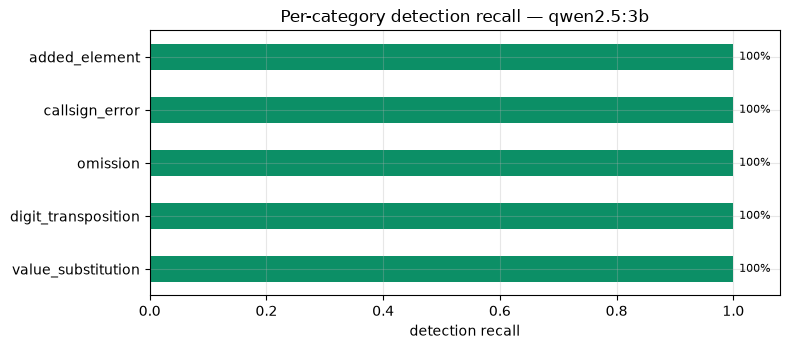

In [9]:
pc = best["per_category"]
cat_df = pd.DataFrame(
    {k: {"n": v["n"], "detection_recall": v["detection_recall"]} for k, v in pc.items()}
).T.sort_values("detection_recall")
ax = cat_df["detection_recall"].plot(kind="barh", figsize=(8, 3.6), color="#0c8f66")
ax.set_xlim(0, 1.08)
ax.set_xlabel("detection recall")
ax.set_title(f"Per-category detection recall — {best['model']}")
for i, v in enumerate(cat_df["detection_recall"]):
    ax.text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Failure analysis
The remaining verdict failures for the best run, with the model's extracted fields, so each
cause can be diagnosed (extraction error vs. label ambiguity). These seed the report's
failure-mode section.

In [10]:
pred = None
for rel in ("eval/results/runs/3b_final_v3", "eval/results/runs/3b_baseline_v1"):
    p = ROOT / rel / "predictions.csv"
    if p.exists():
        pred = pd.read_csv(p)
        break
fails = pred.loc[~pred["verdict_correct"].astype(bool)]
print(f"{len(fails)} verdict failure(s):")
cols = ["id", "instruction", "readback", "gold_verdict", "pred_verdict", "pred_categories"]
fails[cols].reset_index(drop=True)

1 verdict failure(s):


,id,instruction,readback,gold_verdict,pred_verdict,pred_categories
0,TC12,"Easy 4471, reduce speed 210 knots, descend fli...","Speed 210 knots, descend flight level 100, Eas...",MATCH,DISCREPANCY,added_element


In [11]:
# Drill into one failure: the extracted fields reveal the cause.
if len(fails):
    row = fails.iloc[0]
    print("id:", row["id"])
    print("instruction:", row["instruction"])
    print("readback   :", row["readback"])
    print("gold       :", row["gold_verdict"], "/", row["gold_category"])
    print("predicted  :", row["pred_verdict"], "/", row["pred_categories"])
    print("extracted (instruction):", row["instruction_extracted"])
    print("extracted (readback)   :", row["readback_extracted"])

id: TC12
instruction: Easy 4471, reduce speed 210 knots, descend flight level 100.
readback   : Speed 210 knots, descend flight level 100, Easy 4471.
gold       : MATCH / correct
predicted  : DISCREPANCY / added_element
extracted (instruction): {"callsign": "Easy 4471", "altitude": null, "heading": null, "speed": 210, "frequency": null, "squawk": null, "runway": null, "qnh": null}
extracted (readback)   : {"callsign": "Easy 4471", "altitude": {"kind": "FL", "value": 100}, "heading": null, "speed": 210, "frequency": null, "squawk": null, "runway": null, "qnh": null}


## 8. Takeaways

- The **deterministic comparator is reliable** — its logic is unit-tested and is not the source
  of the errors.
- The **extraction step is the bottleneck**: the small model hallucinates fields (notably runway
  side, and callsign digits as squawk).
- **Prompt examples can backfire**: aggressive few-shot examples poisoned extraction and *raised*
  the false-alarm rate. Safe **rules** plus a deterministic **comparator rule** were better levers.
- Model capacity matters: compare the 3B and 7B rows above.
- A reproducible eval harness made this iteration measurable rather than anecdotal.

_All numbers and figures above are produced from the committed `eval/results/runs/` artifacts._